## Student Performance Indicator 

#### Project Workflow

- Understanding the Problem Statement
- Data Collection
- Data Checks to Perform
- Exploratory Data Analysis
- Data Pre-Processing
- Model Training
- Choose Best Model

1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
The data consists of 8 column and 1000 rows.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Data/raw.csv")

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group C,associate's degree,standard,none,91,86,84
1,female,group B,some college,free/reduced,completed,53,66,73
2,male,group D,bachelor's degree,standard,none,80,73,72
3,male,group C,some college,free/reduced,none,74,77,73
4,male,group E,some college,standard,completed,84,83,78


In [5]:
df.shape

(199, 8)

In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df[df.duplicated()] # this will check which rows are duplicated

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score


In [9]:
df[df.duplicated(keep=False)]  # this will check which rows are duplicated and will show all the duplicates 

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       199 non-null    str  
 1   race_ethnicity               199 non-null    str  
 2   parental_level_of_education  199 non-null    str  
 3   lunch                        199 non-null    str  
 4   test_preparation_course      199 non-null    str  
 5   math_score                   199 non-null    int64
 6   reading_score                199 non-null    int64
 7   writing_score                199 non-null    int64
dtypes: int64(3), str(5)
memory usage: 12.6 KB


In [11]:
df.drop_duplicates(inplace=True) # this will drop the duplicates and keep only the first occurrence of the duplicate rows .

In [12]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     60
reading_score                  60
writing_score                  63
dtype: int64

In [13]:
df.describe()

,math_score,reading_score,writing_score
count,199.000000,199.000000,199.000000
mean,64.477387,67.592965,66.417085
std,15.675956,15.111710,15.597912
min,0.000000,17.000000,10.000000
25%,55.000000,57.000000,56.000000
50%,66.000000,70.000000,69.000000
75%,76.000000,78.000000,77.000000
max,100.000000,99.000000,100.000000


Exploring Data 

In [14]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group C,associate's degree,standard,none,91,86,84
1,female,group B,some college,free/reduced,completed,53,66,73
2,male,group D,bachelor's degree,standard,none,80,73,72
3,male,group C,some college,free/reduced,none,74,77,73
4,male,group E,some college,standard,completed,84,83,78


In [15]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:   <StringArray>
['group C', 'group B', 'group D', 'group E', 'group A']
Length: 5, dtype: str
Categories in'parental level of education' variable: <StringArray>
['associate's degree',       'some college',  'bachelor's degree',
   'some high school',        'high school',    'master's degree']
Length: 6, dtype: str
Categories in 'lunch' variable:      <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:      <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [16]:
# define numerical & categorical columns
numeric_features = df.select_dtypes(exclude=['object', 'string']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'string', 'str']).columns.tolist()

# print columns
print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"\nWe have {len(categorical_features)} categorical features: {categorical_features}")

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [17]:
# Adding columns for "Total score" and "average"
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group C,associate's degree,standard,none,91,86,84,261,87.000000
1,female,group B,some college,free/reduced,completed,53,66,73,192,64.000000
2,male,group D,bachelor's degree,standard,none,80,73,72,225,75.000000
3,male,group C,some college,free/reduced,none,74,77,73,224,74.666667
4,male,group E,some college,standard,completed,84,83,78,245,81.666667


In [18]:
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 1
Number of students with full marks in Writing: 1
Number of students with full marks in Reading: 0


In [19]:
reading_less_20 = df[df['reading_score'] < 20]['average'].count()
writing_less_20 = df[df['writing_score'] < 20]['average'].count()
math_less_20 = df[df['math_score'] < 20]['average'].count()

print(f'number of students with less thean 20 marks in maths:{math_less_20}')
print(f'number of students with less then 20 marks in writing: { writing_less_20}')
print(f'number of students with less then 20 marks in reading:{reading_less_20}')

number of students with less thean 20 marks in maths:2
number of students with less then 20 marks in writing: 2
number of students with less then 20 marks in reading:1


In [20]:
# From above value we get students performed worst in maths and writing
# and students performed well in reading.

##### Exploring Data Visualization

<Axes: xlabel='average', ylabel='Count'>

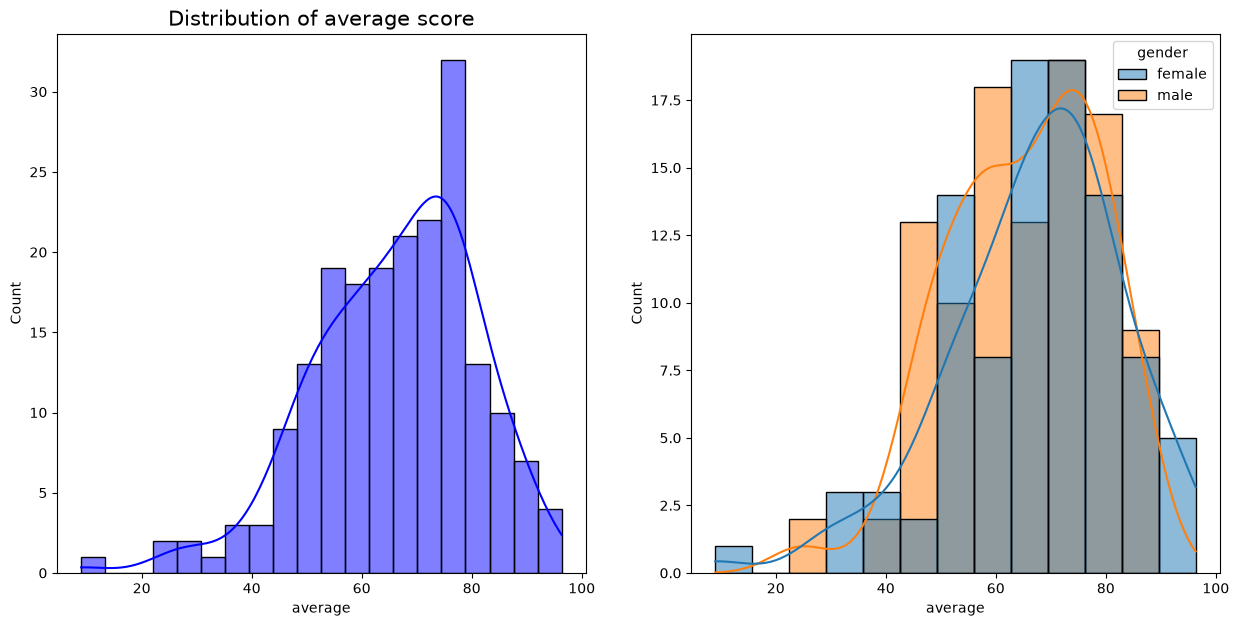

In [21]:
fig, axis = plt.subplots(1,2, figsize =(15, 7))
plt.subplot(1,2,1)
sns.histplot(data = df, x= 'average', bins= 20, kde = True, color = 'blue')
plt.title('Distribution of average score', fontsize = 15)
plt.subplot(1,2,2)
sns.histplot(data =df, x='average',kde= True, hue= 'gender' )

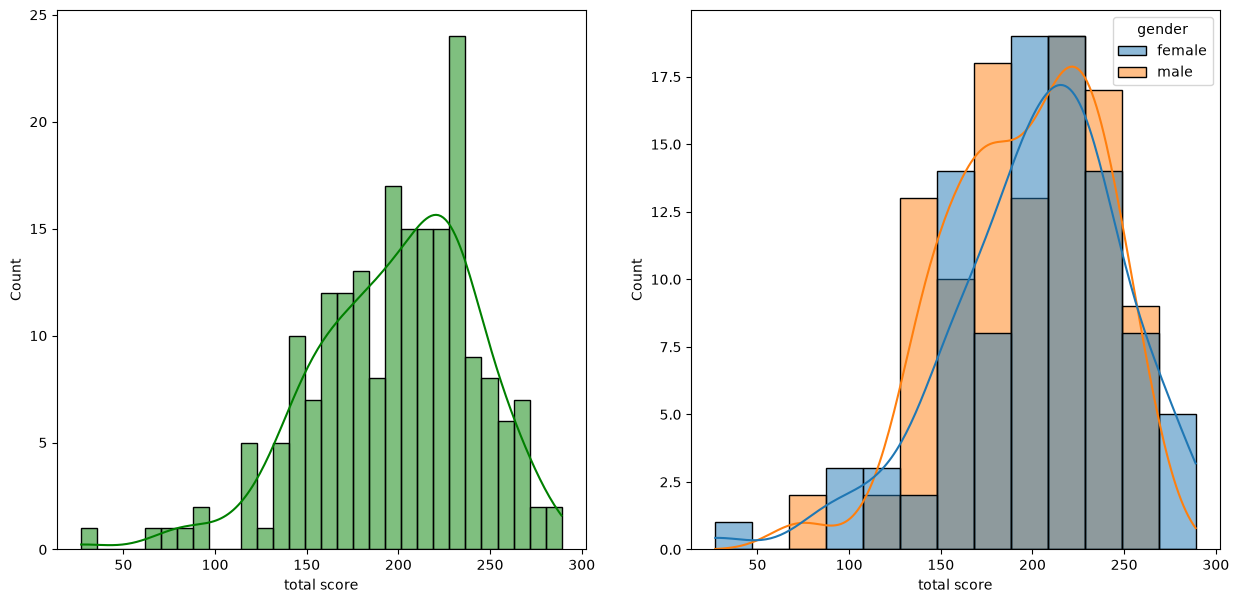

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(1,2,1)
sns.histplot(data=df,x='total score',bins=30,kde=True,color='g')
plt.subplot(1,2,2)
sns.histplot(data=df,x='total score',kde=True,hue='gender')
plt.show()

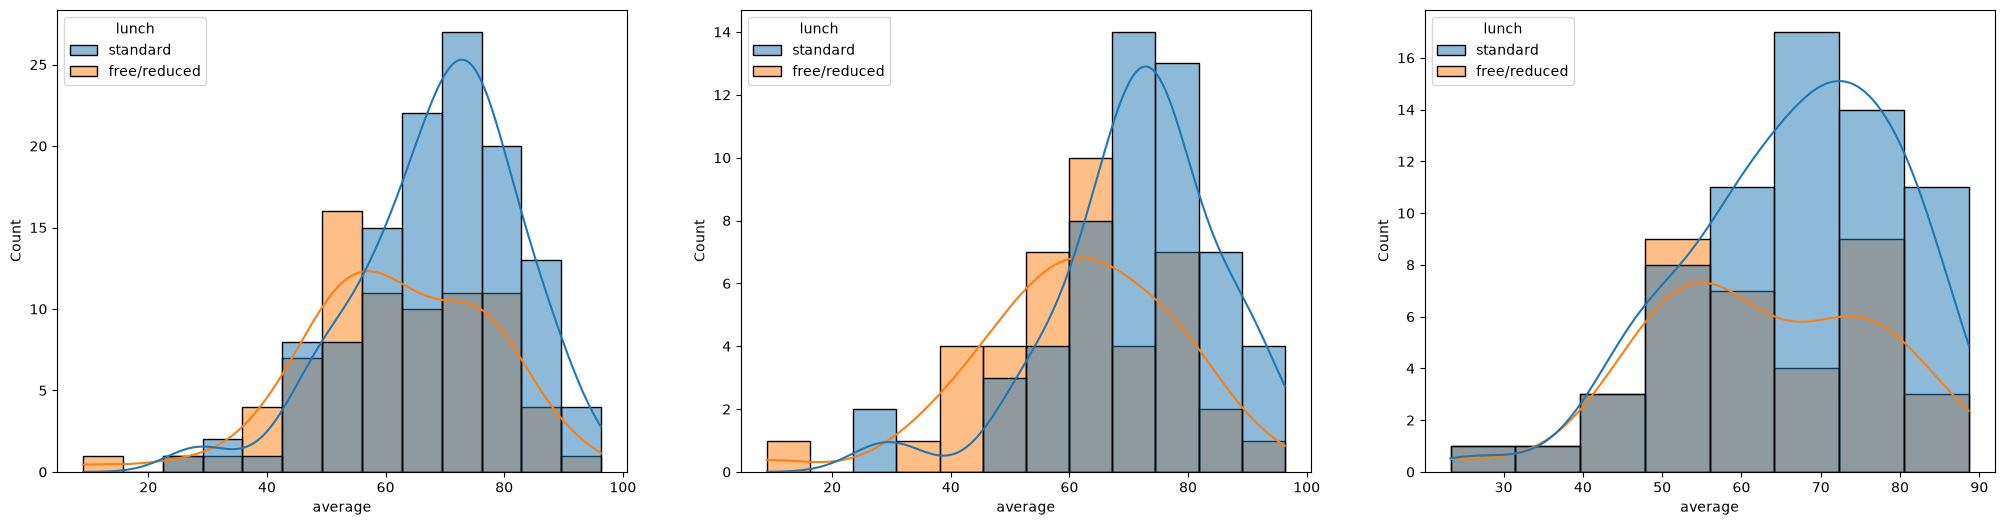

In [23]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1,3,1)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(1,3,2)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(1,3,3)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

In [24]:
# these tells that who take standard lunch performed better than who take  free/reduced lunch.

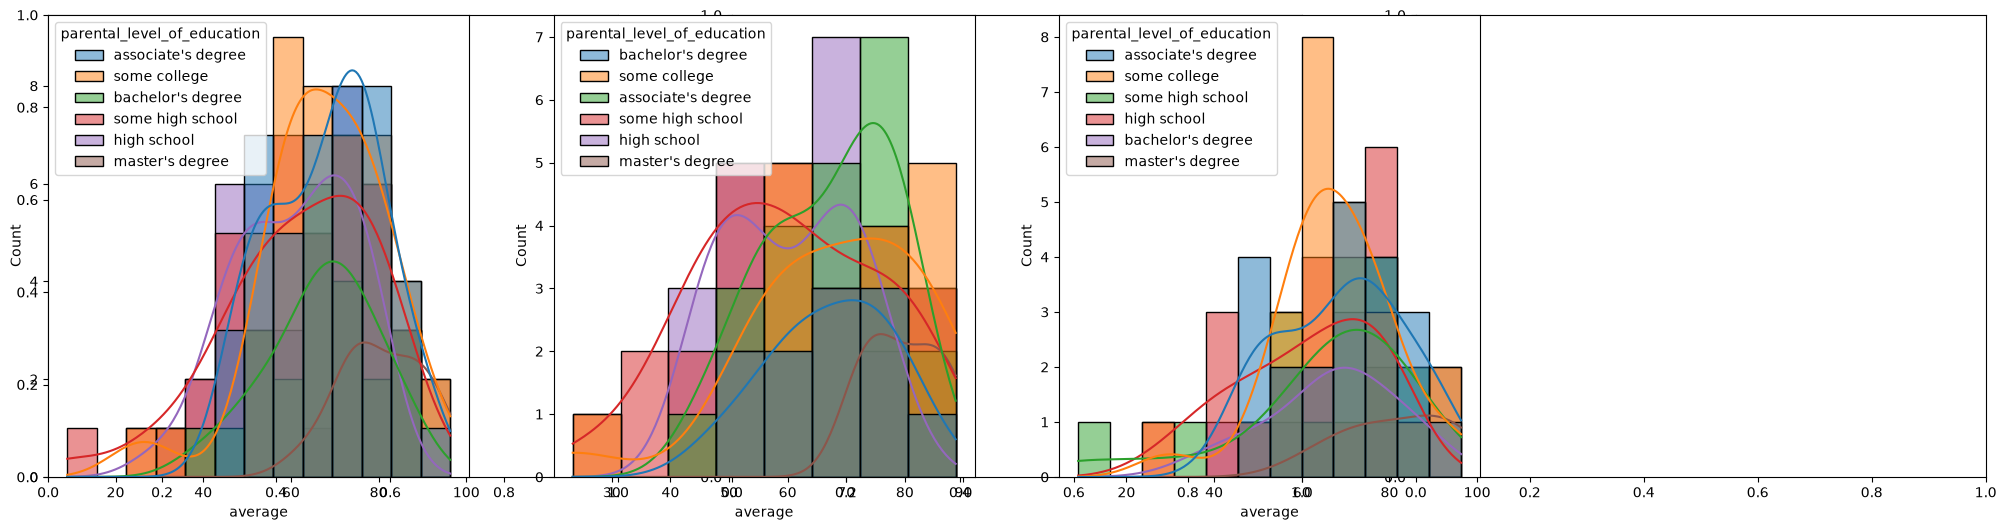

In [25]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1,4,1)
ax =sns.histplot(data=df,x='average',kde=True,hue='parental_level_of_education')
plt.subplot(1,4,2)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental_level_of_education')
plt.subplot(1,4,3)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental_level_of_education')
plt.show()

In [26]:
# In genral students whose parents have higher education performed better than students whose parents have lower education level.
# 2nd plot shows that male students whose parents have higher education performed better than male students whose parents have lower education level
# 3rd plot shows that female students whose parents have higher education performed better then female whose parents have lower education level.

In [27]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group C,associate's degree,standard,none,91,86,84,261,87.000000
1,female,group B,some college,free/reduced,completed,53,66,73,192,64.000000
2,male,group D,bachelor's degree,standard,none,80,73,72,225,75.000000
3,male,group C,some college,free/reduced,none,74,77,73,224,74.666667
4,male,group E,some college,standard,completed,84,83,78,245,81.666667


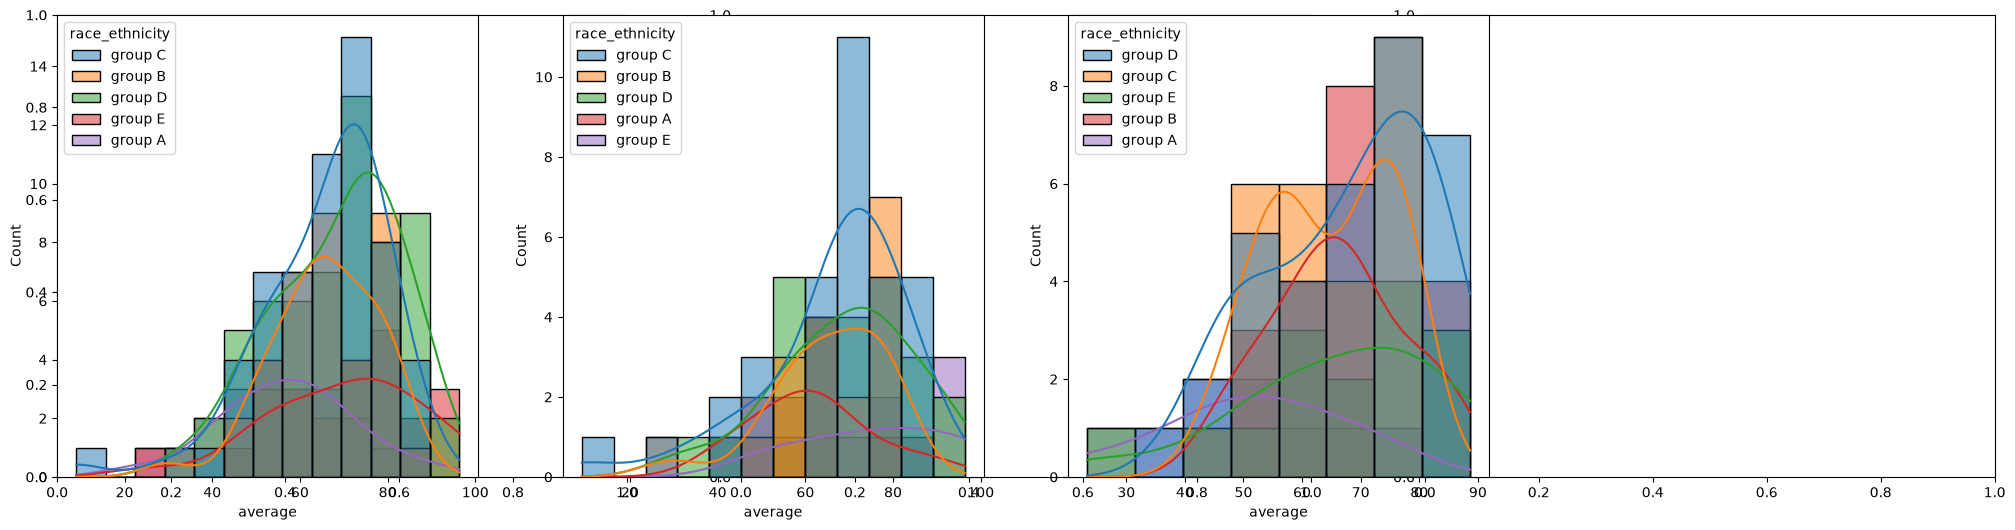

In [28]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1,4,1)
ax =sns.histplot(data=df,x='average',kde=True,hue='race_ethnicity')
plt.subplot(1,4,2)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race_ethnicity')
plt.subplot(1,4,3)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race_ethnicity')
plt.show()

In [29]:
# students from group E perrformed better than students from group D, C, B and A.

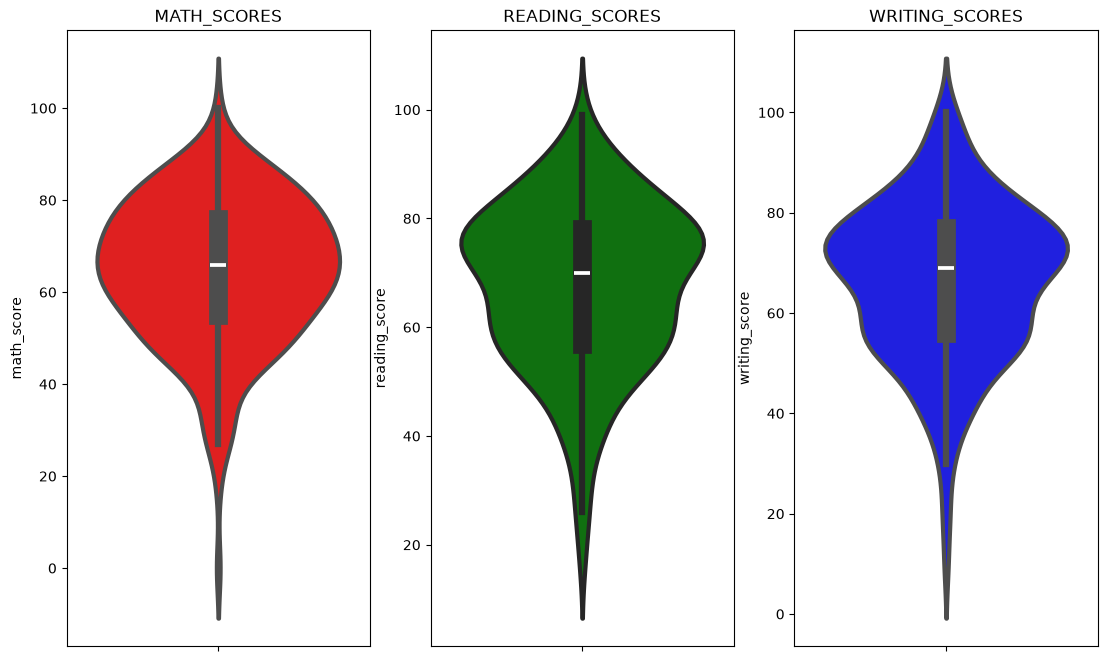

In [30]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH_SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING_SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING_SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

In [31]:
# In the above violin plots we can see that the Distribution of reading score is more than the distribution of writing score and the distribution of writing score is more then the distribution of math score 
# and most of the students have reading score between 60 to 80, writing score between 50 to 70 and math score between 40 to 60.

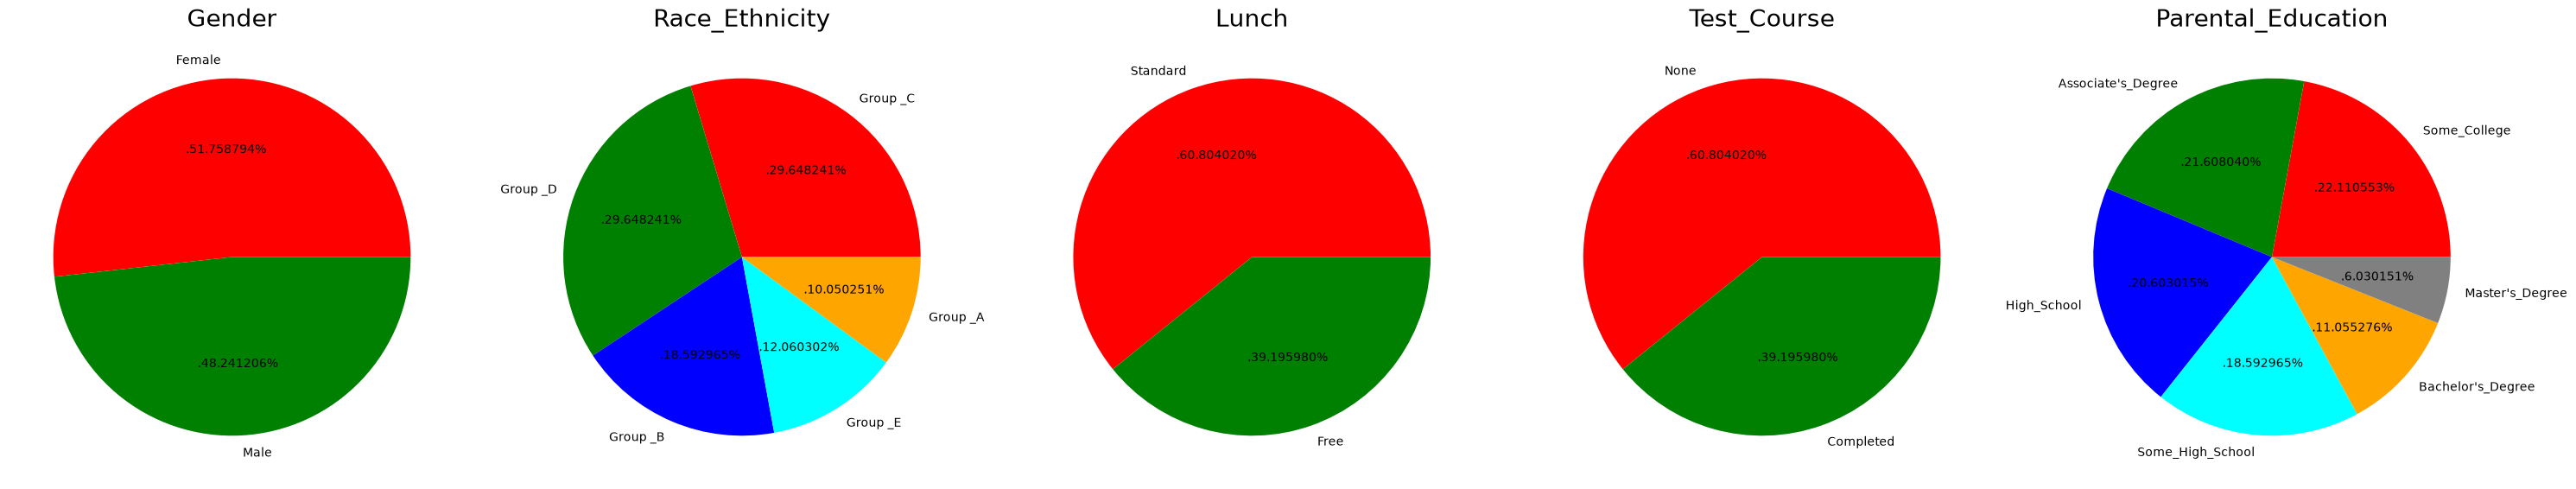

In [32]:
#  Multivariate analysis using pieplot
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group _C', 'Group _D','Group _B','Group _E','Group _A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race_Ethnicity', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test_Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some_College', "Associate's_Degree",'High_School','Some_High_School',"Bachelor's_Degree","Master's_Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental_Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

In [33]:
# Number of male and female students are almost equal in the dataset.
# Numbers os students from group C are more then the numbers of students from group D, B, E, A.
# Numbers of students who take standard lunch are more then the numbers of students who take free/reduced lunch.
# Numbers of students who did not take test preparation course are more then the numbers of students who took test preparation course.
# Numbers of students with parental education levels of some college, associate's degree, and bachelor's degree are more then the numbers of students with other parental education levels.

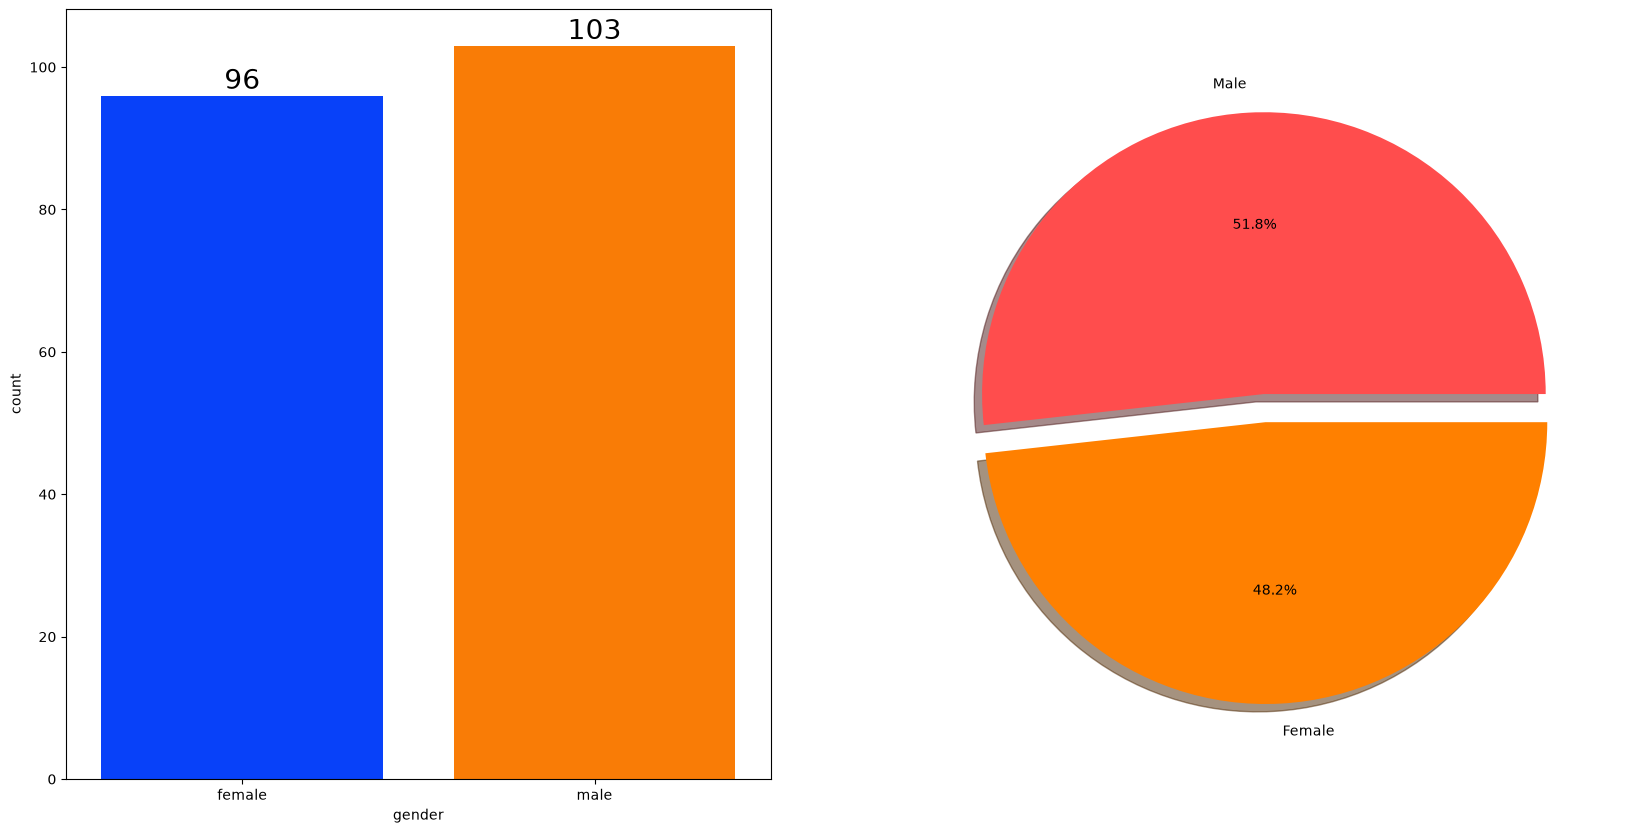

In [34]:
# UNIVARIATE ANALYSIS ( How is distribution of Gender ? )
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

In [35]:
# Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

In [36]:
# BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,total score,average
gender,,,,,
female,60.645833,70.531250,70.427083,201.604167,67.201389
male,68.048544,64.854369,62.679612,195.582524,65.194175


In [37]:
# plt.figure(figsize=(10, 8))

# X = ['Total Average','Math Average']


# male_scores = [gender_group['average'].loc['male'], gender_group['math_score'].loc['male']]
# female_scores = [gender_group['average'].loc['female'], gender_group['math_score'].loc['female']]

# X_axis = np.arange(len(X))
  
# plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
# plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
# plt.xticks(X_axis, X)
# plt.ylabel("Marks")
# plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
# plt.legend()
# plt.show()

In [38]:
# On an average female performed better than men 
# Where as in math male performed better than women.

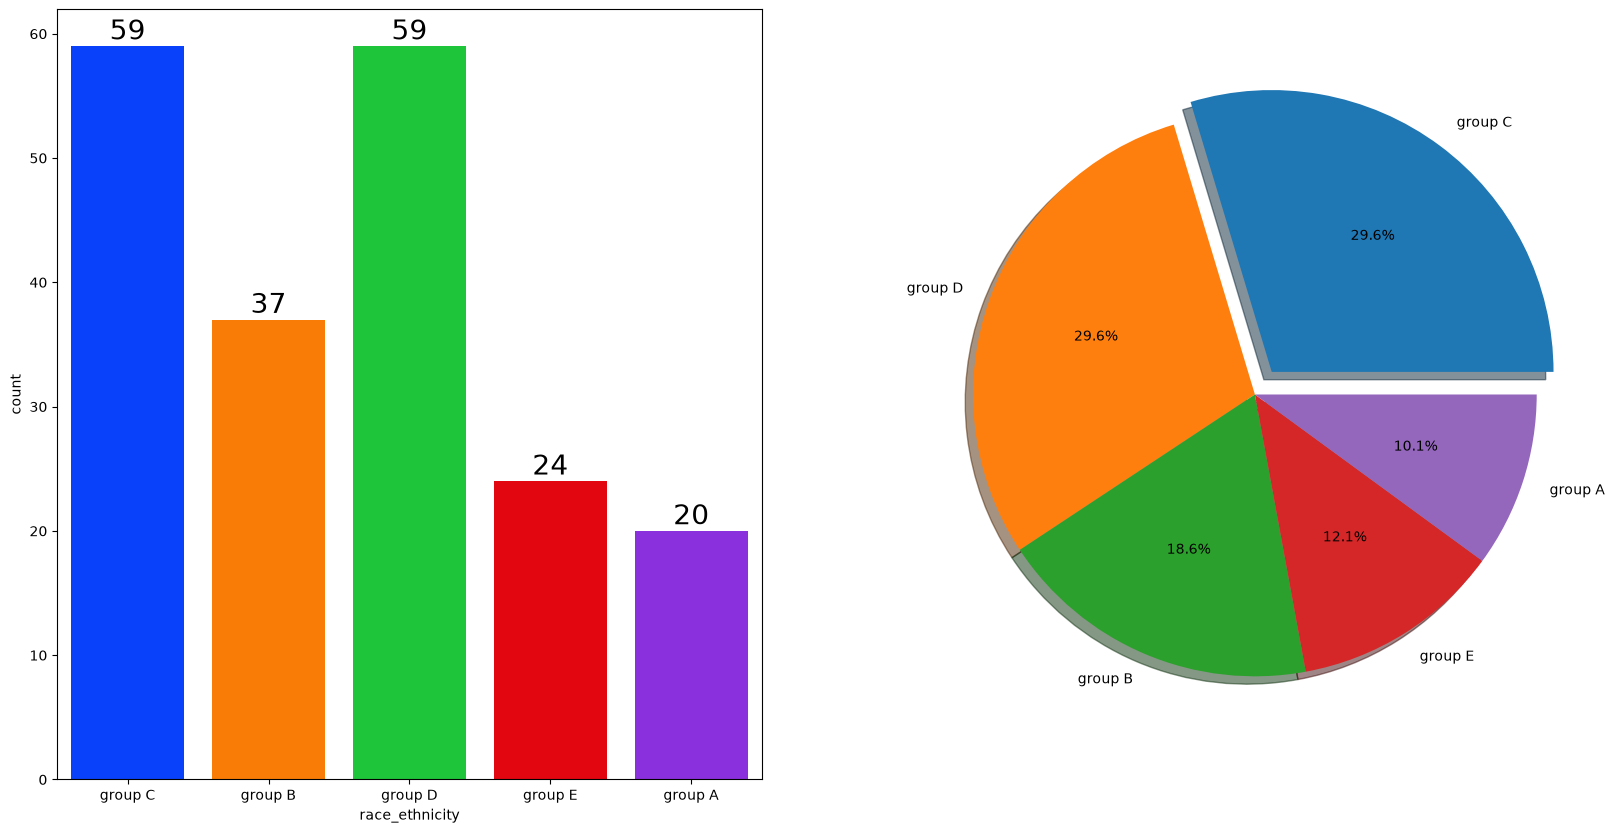

In [39]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show() 

In [40]:
# Most of the students are from Group C/ Group D and least of the students are from Group A.

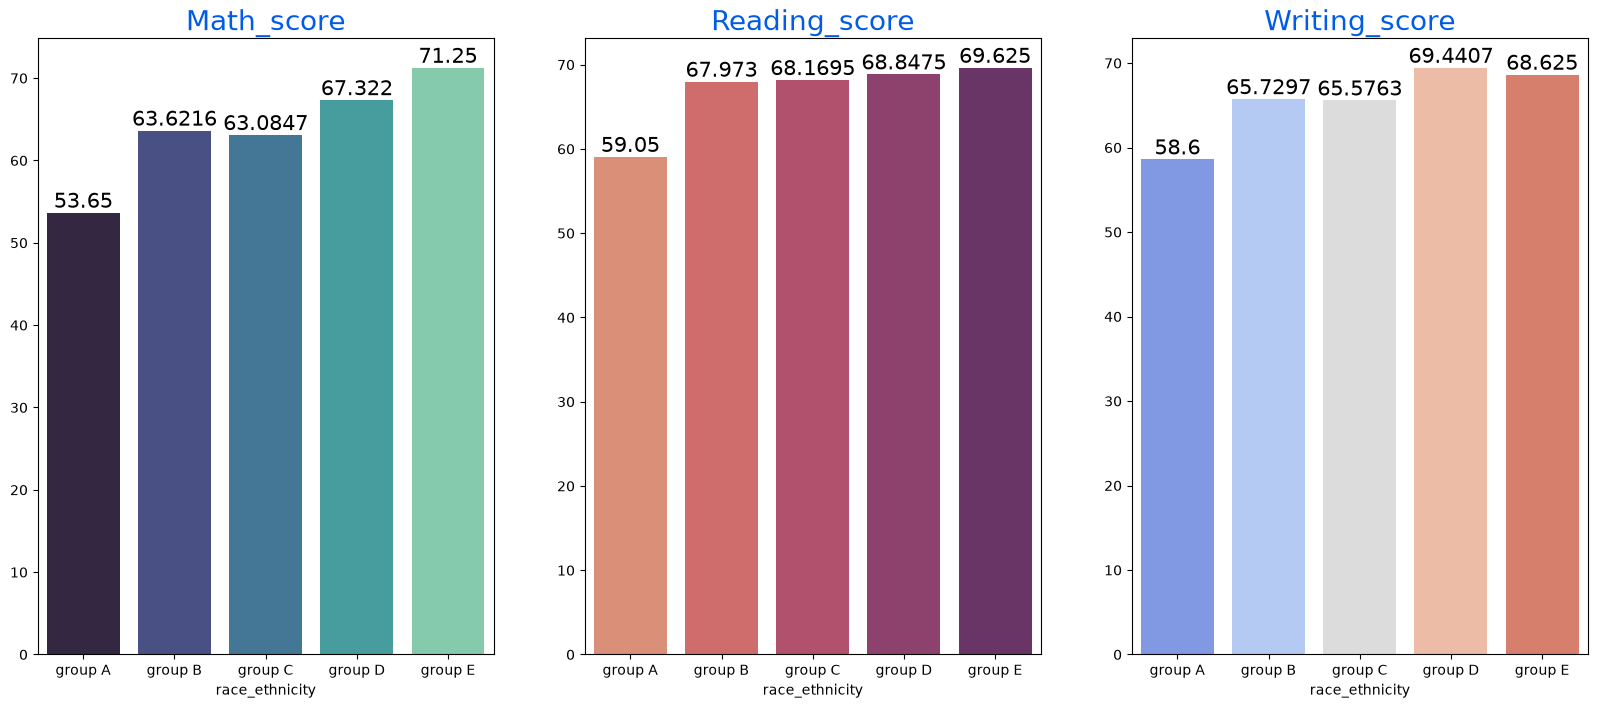

In [41]:
# BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math_score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading_score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing_score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

In [42]:
# Overall Group E students performed better than students from group D,C,B and A.

findfont: Failed to find font weight 30, now using 400.


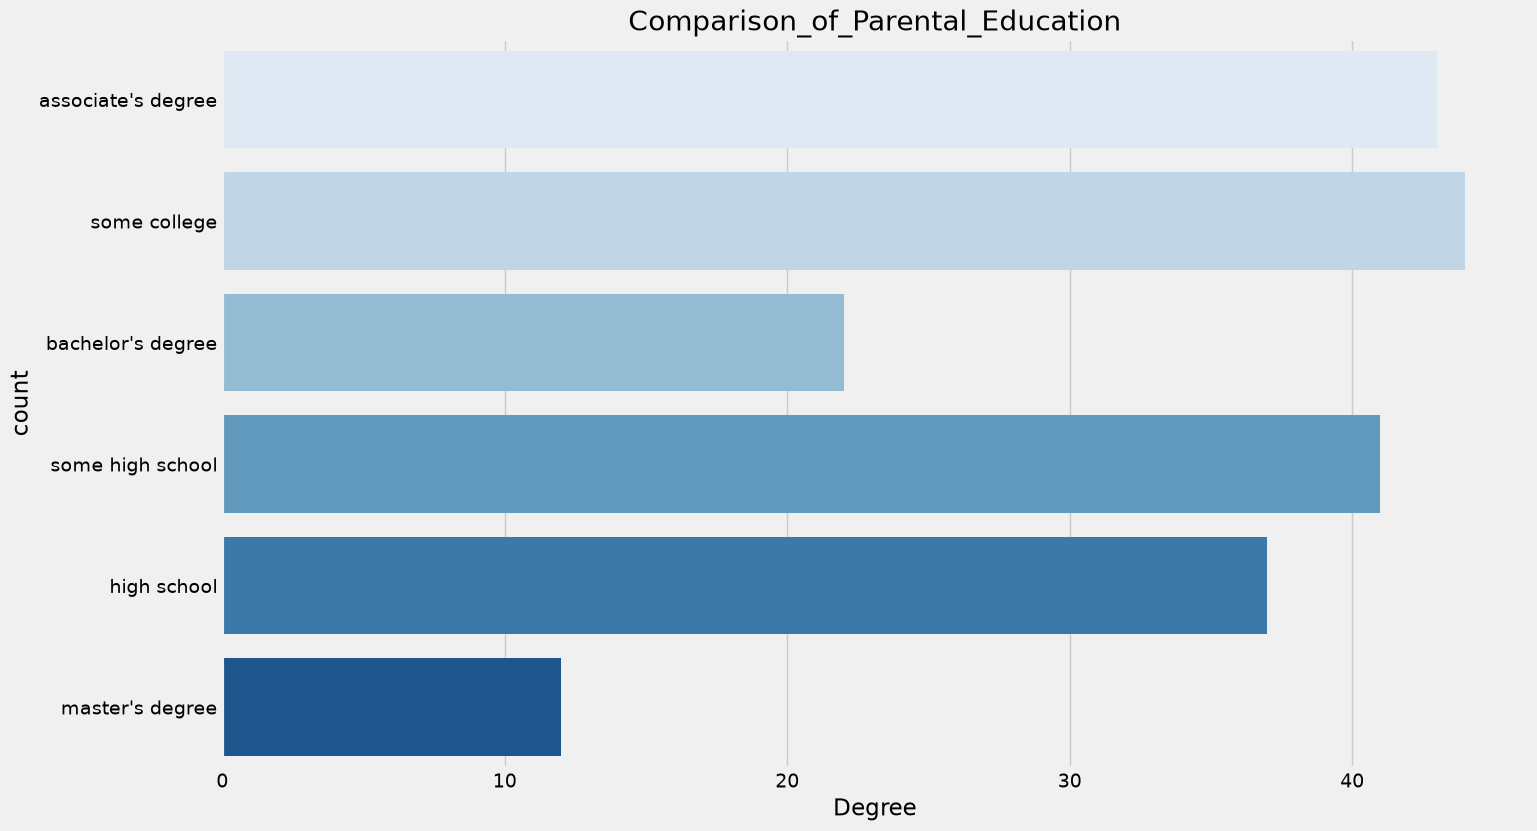

In [43]:
# UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison_of_Parental_Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

In [44]:
# Largest number of students have parents with some college education.

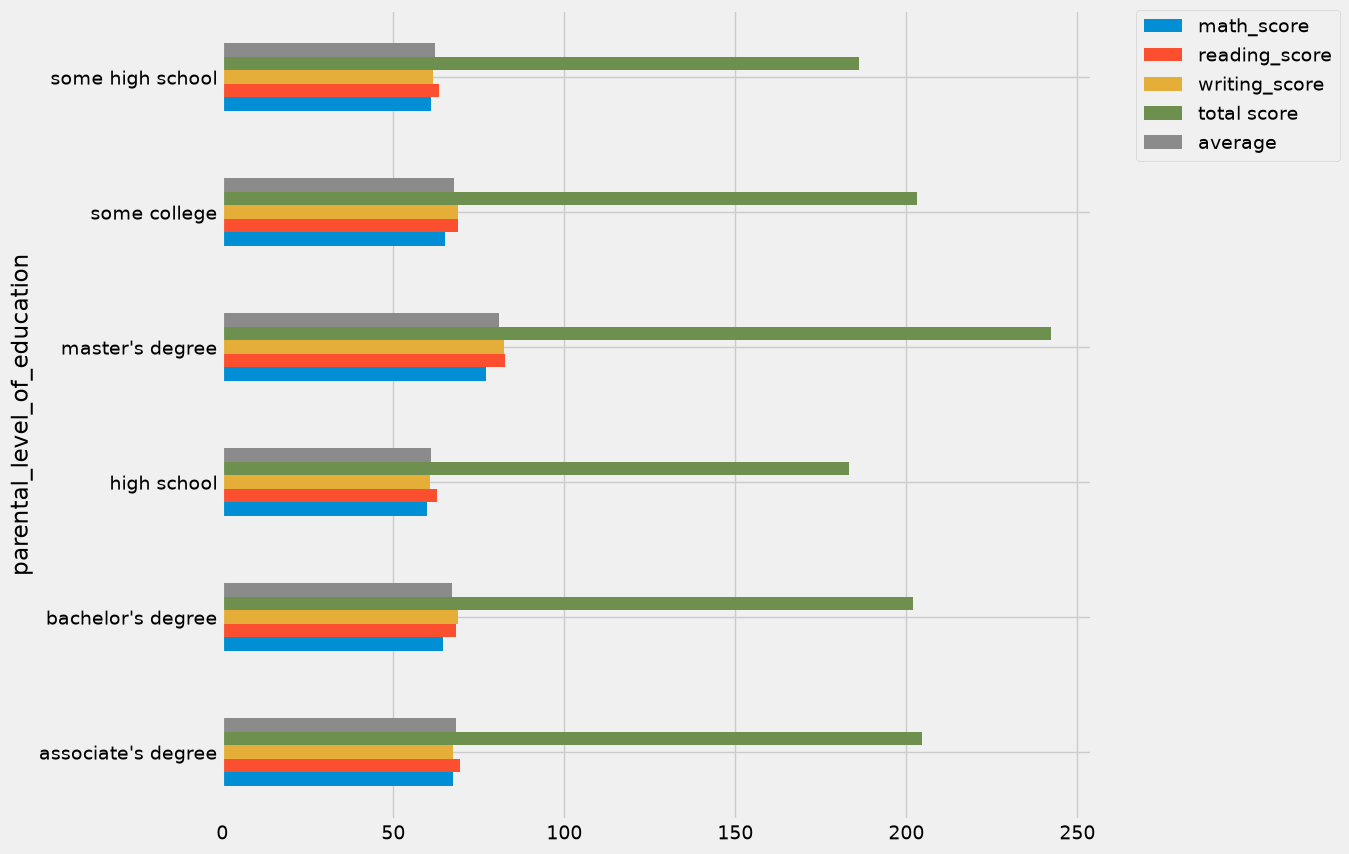

In [45]:
# BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )
df.groupby('parental_level_of_education').mean(numeric_only=True).plot(kind='barh', figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [46]:
# The score of students whose parents posses master's degree and bachelor's degree is higher than the others students .

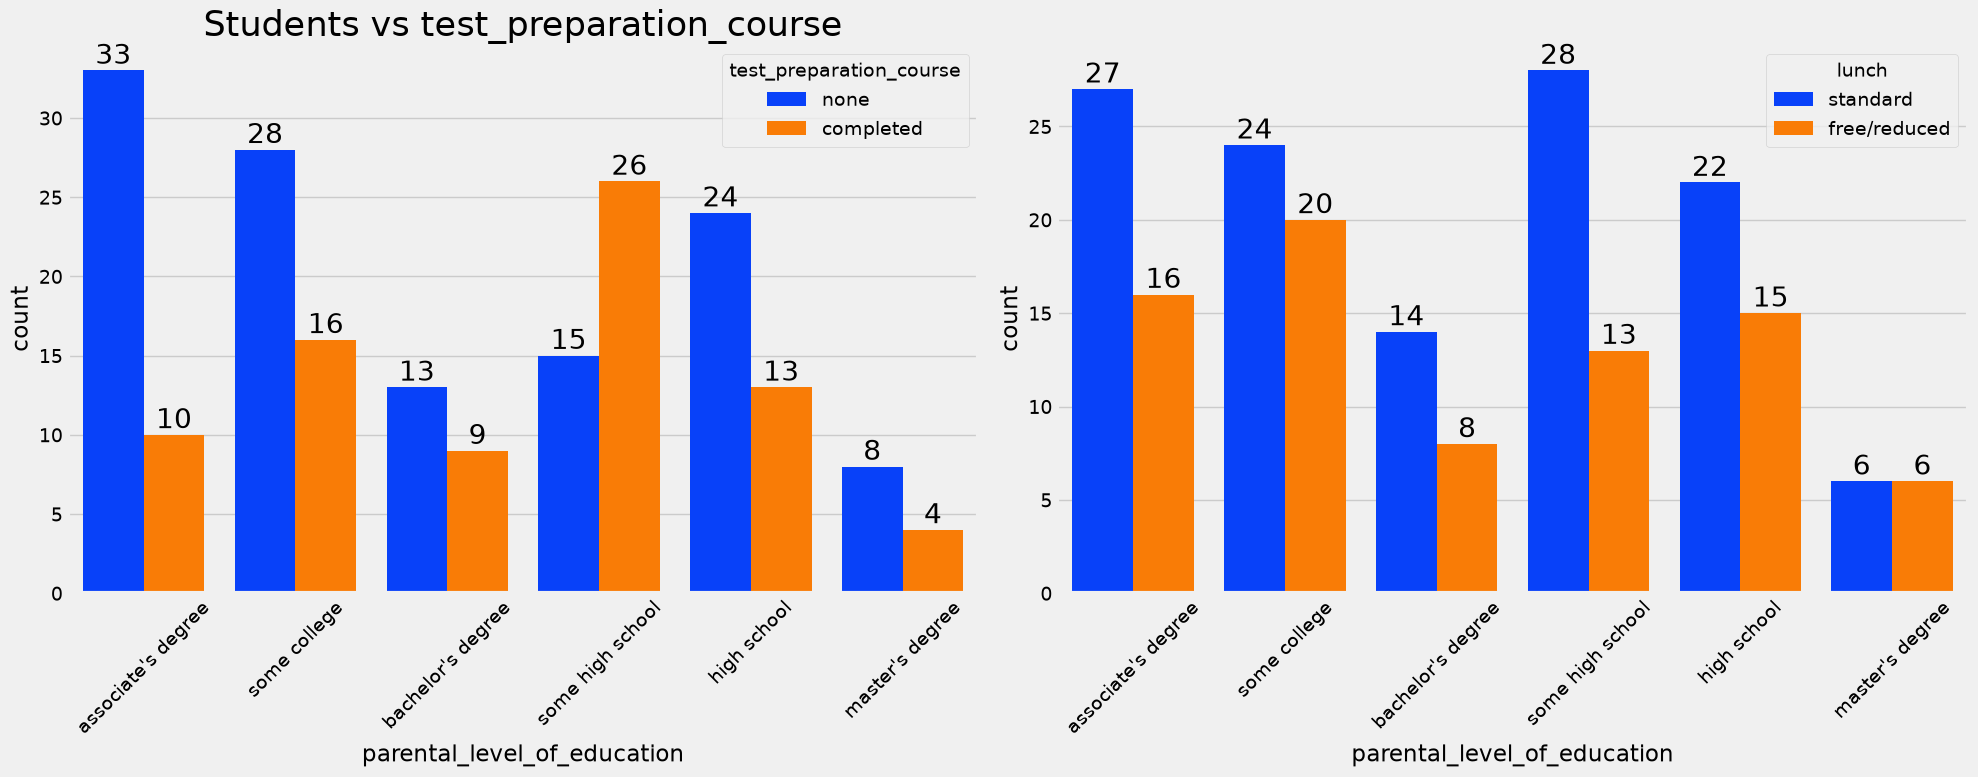

In [47]:
# BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )
f, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.countplot(
    x=df['parental_level_of_education'],
    data=df,
    palette='bright',
    hue='test_preparation_course',
    saturation=0.95,
    ax=ax[0]
)
ax[0].set_title('Students vs test_preparation_course', color='black', size=25)
ax[0].tick_params(axis='x', labelrotation=45)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

sns.countplot(
    x=df['parental_level_of_education'],
    data=df,
    palette='bright',
    hue='lunch',
    saturation=0.95,
    ax=ax[1]
)
ax[1].tick_params(axis='x', labelrotation=45)

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=20)

plt.tight_layout()
plt.show()

In [48]:
# Student who got standard lunch have perforned better than the students who get the free/reuced lunch.

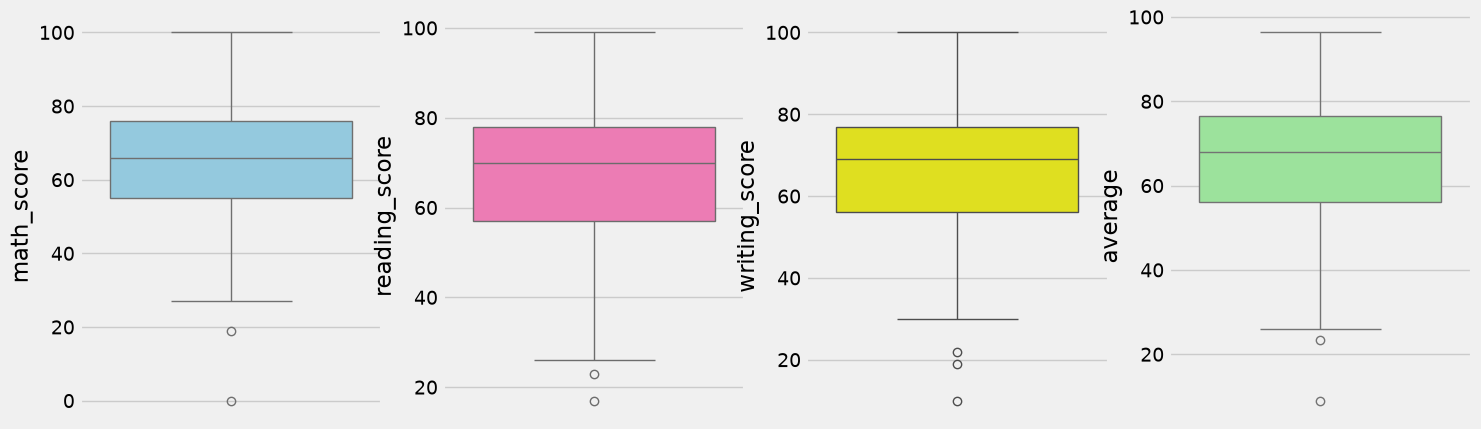

In [49]:
# Checking outliers in the dataset using boxplot
plt.subplots(1,4,figsize=(16,5))
plt.subplot(1,4,1)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(1,4,2)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(1,4,3)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(1,4,4)
sns.boxplot(df['average'],color='lightgreen')
plt.show()


In [50]:
#  From the above boxplot we can see that there are some outliers in the dataset but we will not remove them because they are val id data points and they are not due to any error in data collection or data entry.

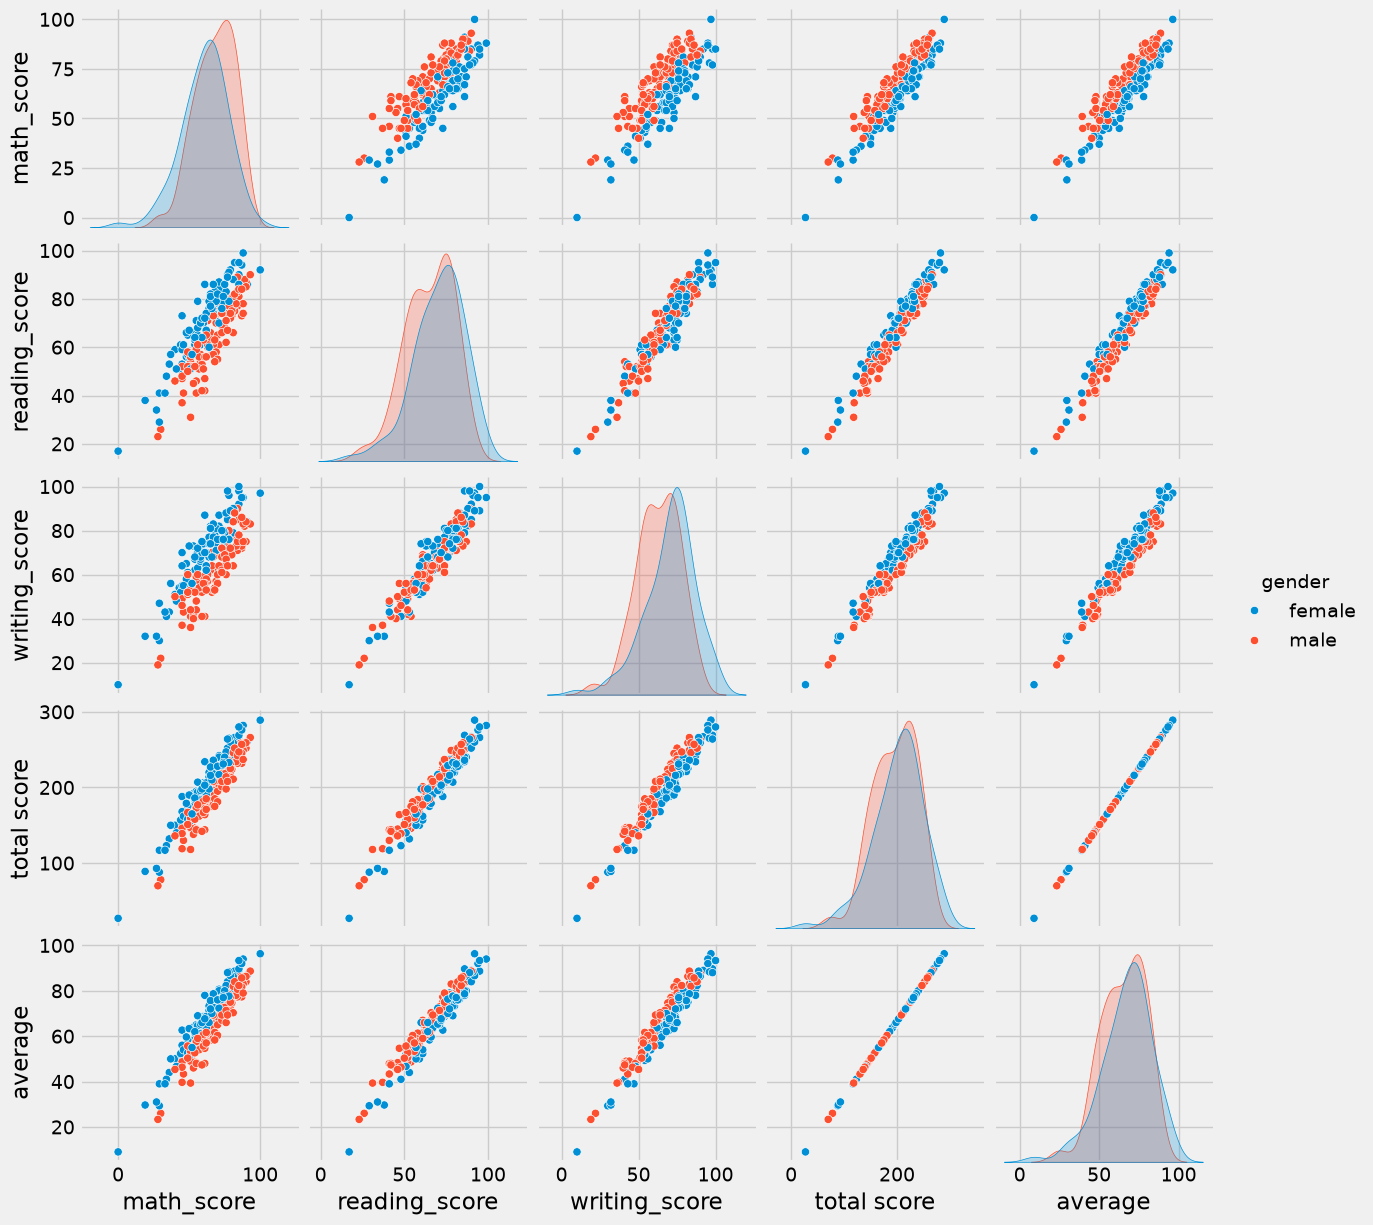

In [51]:
# Multivariate analysis using pairplot
sns.pairplot(df,hue = 'gender')
plt.show()

In [52]:
#  From the above plot it is clear that all the scores are increases lineraly with each other . 